In [ ]:
mode = 'train_offline'

In [8]:
import onnxruntime as ort
import librosa
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
import os
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
if "offline" in mode:
    print('working offline')
    import tensorflow as tf
    import math
    import soundfile as sf
    import mlflow
    tf.config.set_visible_devices([], 'GPU')  # force CPU
elif "online" in mode or mode == 'submit':
    %pip install -q --no-deps /kaggle/input/datasets/dangthaigiang/perch-v2-cpu-onnx-head/onnxruntime-1.24.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl


working offline


I0000 00:00:1778031089.100408   31612 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [9]:

kaggle_onnx_path = '/kaggle/input/datasets/dangthaigiang/perch-v2-cpu-onnx-head/perch_v2.onnx'
onnx_path_dict = {
    'train_offline': '../models/perch_onnx/perch_v2.onnx',
    'train_online': kaggle_onnx_path,
    'submit': kaggle_onnx_path,
    'test_submit': kaggle_onnx_path,
}

working offline


In [10]:

onnx_path = onnx_path_dict[mode]
session_option = ort.SessionOptions()
session_option.intra_op_num_threads = 4
onnx_session = ort.InferenceSession(onnx_path, session_options = session_option, providers = ['CPUExecutionProvider'])
onnx_ipt_name = onnx_session.get_inputs()[0].name
# print(f'Onnx input ame: {onnx_ipt_name}')
onnx_opt_map = {o.name: i for i, o in enumerate(onnx_session.get_outputs())}
# print(f'Onnx output maps: {onnx_opt_map}')

## Load a 5-second .ogg chunk → numpy array at 32 kHz

Perch v2 expects `float32` waveform, shape `(batch, 160000)`, at **32 kHz**.

In [11]:

SAMPLE_RATE = 32000
CHUNK_SECONDS = 5
CHUNK_SAMPLES = SAMPLE_RATE * CHUNK_SECONDS  # 160000

def load_chunk(path: str, offset_sec: float) -> np.ndarray:
    """Load one 5-second chunk from an .ogg file.
    
    Returns float32 array of shape (160000,), ready for Perch v2.
    """
    waveform, _ = librosa.load(
        path,
        sr=SAMPLE_RATE,
        offset=offset_sec,
        duration=CHUNK_SECONDS,
        mono=True,
    )
    # Pad if the file ends before 5 seconds
    if len(waveform) < CHUNK_SAMPLES:
        waveform = np.pad(waveform, (0, CHUNK_SAMPLES - len(waveform)))
    return waveform.astype(np.float32)

# Quick sanity check on one file
# sample_path = '/kaggle/input/competitions/birdclef-2026/train_audio/1161364/iNat1114648.ogg'  
# chunk = load_chunk(sample_path, offset_sec=0.0)
# print('Shape:', chunk.shape)   # (160000,)
# print('dtype:', chunk.dtype)   # float32
# print('Range:', chunk.min(), chunk.max())

In [12]:
def extract_embedding(waveform: np.ndarray) -> np.ndarray:
    """waveform: (160000,) float32  →  embedding: (1536,) float32"""
    inp = waveform[np.newaxis, :]
    outs = onnx_session.run(None, {onnx_ipt_name: inp})
    emb  = outs[onnx_opt_map['embedding']].astype(np.float32)
    return emb  # (1536,)

# emb = extract_embedding(chunk)
# print(f'Embedding shape: {emb.shape}')

## Set up model

In [51]:
NUM_TRAIN_CLASSES = 234
EMBED_DIM = 1536

class PerchHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.BatchNorm1d(EMBED_DIM),
            nn.Dropout(0.3),
            nn.Linear(EMBED_DIM, 512),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(512, NUM_TRAIN_CLASSES),
        )
    def forward(self, x):
        return self.net(x)

head = PerchHead()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
use_previous_model = False
print('Device: ', device)
print('Number of classes: ', NUM_TRAIN_CLASSES)

Device:  cuda
Number of classes:  234


In [59]:
def plot_train_history(train_history_df):
    figure, axes = plt.subplots(2, 2, figsize=(15, 8))
    axes = axes.flatten()

    axes[0].plot(train_history_df['epoch'], train_history_df['train loss'])
    axes[0].set_title('Train loss vs Epoch')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Train loss')

    axes[1].plot(train_history_df['epoch'], train_history_df['validation loss'])
    axes[1].set_title('Validation loss vs Epoch')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Validation loss')

    axes[2].plot(train_history_df['epoch'], train_history_df['validation accuracy'])
    axes[2].set_title('Validation accuracy vs Epoch')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Validation Accuracy')

    axes[3].plot(train_history_df['epoch'], train_history_df['validation auc'])
    axes[3].set_title('Validation AUC vs Epoch')
    axes[3].set_xlabel('Epoch')
    axes[3].set_ylabel('Validation AUC')

    plt.tight_layout()
    plt.show()

In [27]:
base_dir = Path('..')
# def get_train_df(base_dir):
train_path = base_dir/'data'/'train.csv'
train_df = pd.read_csv(str(train_path))
train_label_set = sorted(set((train_df['primary_label'].unique())))
print(len(train_label_set))
label2idx = {label: idx for idx, label in enumerate(train_label_set)}
train_df = train_df[['primary_label', 'filename']] # remove other columns for faster processing
train_df['file_path'] = str(base_dir) + '/data/train_audio/' + train_df['filename']
FIXED_LENGTH = 5 # the duration of a standard audio in seconds
def get_chunks_number(file_path:str):
    '''
    returns the number of chunks
    for the file in row idx of train_df
    '''
    return math.ceil(sf.info(file_path).duration/FIXED_LENGTH) # math.ceil to make sure 18.024 -> 4 chunnks, 15 -> 3 chunks
# add new rows for the new chunks separated from long files
new_idx = train_df.index.repeat(train_df['file_path'].apply(get_chunks_number)) 
train_df = train_df.loc[new_idx].reset_index(drop=True)
# add new offsets (offseting from the begining of long files) in seconds  
train_df['offset_sec'] = train_df.groupby('file_path').cumcount()*FIXED_LENGTH
# plan to use Efficientnet model, which requires labels are encoded in number
train_df['encoded_label'] = train_df['primary_label'].map(label2idx)
train_df = train_df[['file_path', 'offset_sec', 'encoded_label']]
train_df.to_parquet('../data/chunks_206.parquet', index=False)

# get_train_df(base_dir)

206


In [ ]:
chunks_df = pd.read_parquet('../data/chunks_206.parquet')
N = len(chunks_df)
lbl_mm = np.memmap('../data/perch_labels_206.npy', dtype = 'int64', mode = 'w+', shape= (N,))
for i, (_, row) in enumerate(chunks_df.iterrows()):
    lbl_mm[i] = row['encoded_label']
lbl_mm.flush()


In [57]:
def train_offline():
    import warnings
    from sklearn.model_selection import train_test_split

    BATCH_SIZE      = 512
    NUM_EPOCHS      = 6
    VAL_FREQUENCY   = 2
    LR              = 1e-3
    train_ratio     = 0.85

    EMB_CACHE = Path('../data/perch_embeddings.npy')
    LBL_CACHE = Path('../data/perch_labels.npy')
    chunks_df = pd.read_parquet('../data/chunks.parquet')
    N = len(chunks_df)
    embeddings = np.memmap(EMB_CACHE, dtype='float32', mode='r', shape=(N, EMBED_DIM))
    labels     = np.memmap(LBL_CACHE, dtype='int64',   mode='r', shape=(N,))
    print("Labels shape: ", labels.shape)

    X = torch.from_numpy(np.array(embeddings))
    y = torch.from_numpy(np.array(labels))
    dataset = TensorDataset(X, y)

    indices = np.arange(N)
    train_idx, val_idx = train_test_split(
        indices, test_size=1-train_ratio, stratify=np.array(labels), random_state=42
    )
    train_ds = torch.utils.data.Subset(dataset, train_idx)
    val_ds   = torch.utils.data.Subset(dataset, val_idx)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    use_previous_model = False
    try:
        best_model_path = sorted(Path('../mlruns').rglob('best_model.pth'), key=lambda p: p.stat().st_mtime)[-1]
        print(f'Found previous model: {best_model_path}')
        if use_previous_model:
            head.load_state_dict(torch.load(str(best_model_path), weights_only=True))
    except (IndexError, FileNotFoundError):
        print("No previous best_model.pth found, starting fresh")

    head.to(device)
    optimizer = torch.optim.AdamW(head.parameters(), lr=LR, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

    mlflow.set_tracking_uri("sqlite:///../mlflow.db")
    mlflow.set_experiment('birdclef2026-perch-v2-cpu-onnx-head')

    best_val_auc = 0.0
    with mlflow.start_run(run_name='perch_v2_cpu_onnx_head') as run:
        run_dir = Path('../mlruns') / run.info.run_id
        run_dir.mkdir(parents=True, exist_ok=True)
        print(f'Saving models to: {run_dir}')

        mlflow.log_params({'epochs': NUM_EPOCHS, 'lr': LR, 'batch_size': BATCH_SIZE,
                           'embed_dim': EMBED_DIM, 'num_classes': NUM_TRAIN_CLASSES,
                           'train_ratio': train_ratio})
        train_history = []
        for epoch in tqdm(range(NUM_EPOCHS), desc=f'Training {NUM_EPOCHS} epochs ...'):
            head.train()
            train_loss = 0.0
            for xb, yb in train_loader:
                xb, yb = xb.to(device), yb.to(device)
                optimizer.zero_grad()
                loss = criterion(head(xb), yb)
                loss.backward()
                optimizer.step()
                train_loss += loss.item()
            train_loss /= len(train_loader)
            scheduler.step()

            if (epoch + 1) % VAL_FREQUENCY == 0:
                head.eval()
                val_loss, correct, total = 0.0, 0, 0
                all_probs, all_labels_list = [], []
                with torch.no_grad():
                    for xb, yb in val_loader:
                        xb, yb = xb.to(device), yb.to(device)
                        preds = head(xb)
                        val_loss += criterion(preds, yb).item()
                        correct  += (preds.argmax(1) == yb).sum().item()
                        total    += len(yb)
                        all_probs.append(torch.softmax(preds, dim=1).cpu().numpy())
                        all_labels_list.append(yb.cpu().numpy())

                val_loss       /= len(val_loader)
                val_acc         = correct / total
                all_probs       = np.concatenate(all_probs)
                all_labels_arr  = np.concatenate(all_labels_list)

                # compute AUC only over classes present in val to avoid nan
                present_classes = np.unique(all_labels_arr)
                all_present_probs = all_probs[:, present_classes]
                all_present_probs = all_present_probs/all_present_probs.sum(axis=1, keepdims=True)
                with warnings.catch_warnings():
                    # ignore the warnings
                    warnings.simplefilter("ignore")
                    val_auc = roc_auc_score(all_labels_arr, all_present_probs,
                                            multi_class='ovr', average='macro',
                                            labels=present_classes)

                mlflow.log_metrics({'train_loss': float(train_loss), 'val_loss': float(val_loss),
                                    'val_acc': float(val_acc), 'val_auc': float(val_auc)}, step=epoch)
                train_history.append({'epoch': epoch, 'train loss': train_loss,
                                      'validation loss': val_loss, 'validation accuracy': val_acc,
                                      'validation auc': val_auc})
                print(f'Epoch {epoch+1:02d}/{NUM_EPOCHS}  '
                      f'train={train_loss:.4f}  val={val_loss:.4f}  acc={val_acc:.4f}  auc={val_auc:.4f}')

                if val_auc > best_val_auc:
                    best_val_auc = val_auc
                    torch.save(head.state_dict(), run_dir / 'best_model.pth')

        torch.save(head.state_dict(), run_dir / 'last_model.pth')
        train_history_df = pd.DataFrame(train_history)
        plot_train_history(train_history_df)
        print(f'Training complete. Best val_auc: {best_val_auc:.4f}')
        return train_history_df

Labels shape:  (265924,)
Found previous model: ../mlruns/88875a8e625946d48a141336214ee6fe/best_model.pth
Saving models to: ../mlruns/1e7f25719f3345f5958a5a0476970838


Training 6 epochs ...:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 02/6  train=1.5669  val=1.5778  acc=0.8419  auc=0.9937
Epoch 04/6  train=1.4947  val=1.5487  acc=0.8480  auc=0.9945
Epoch 06/6  train=1.4405  val=1.5346  acc=0.8515  auc=0.9946


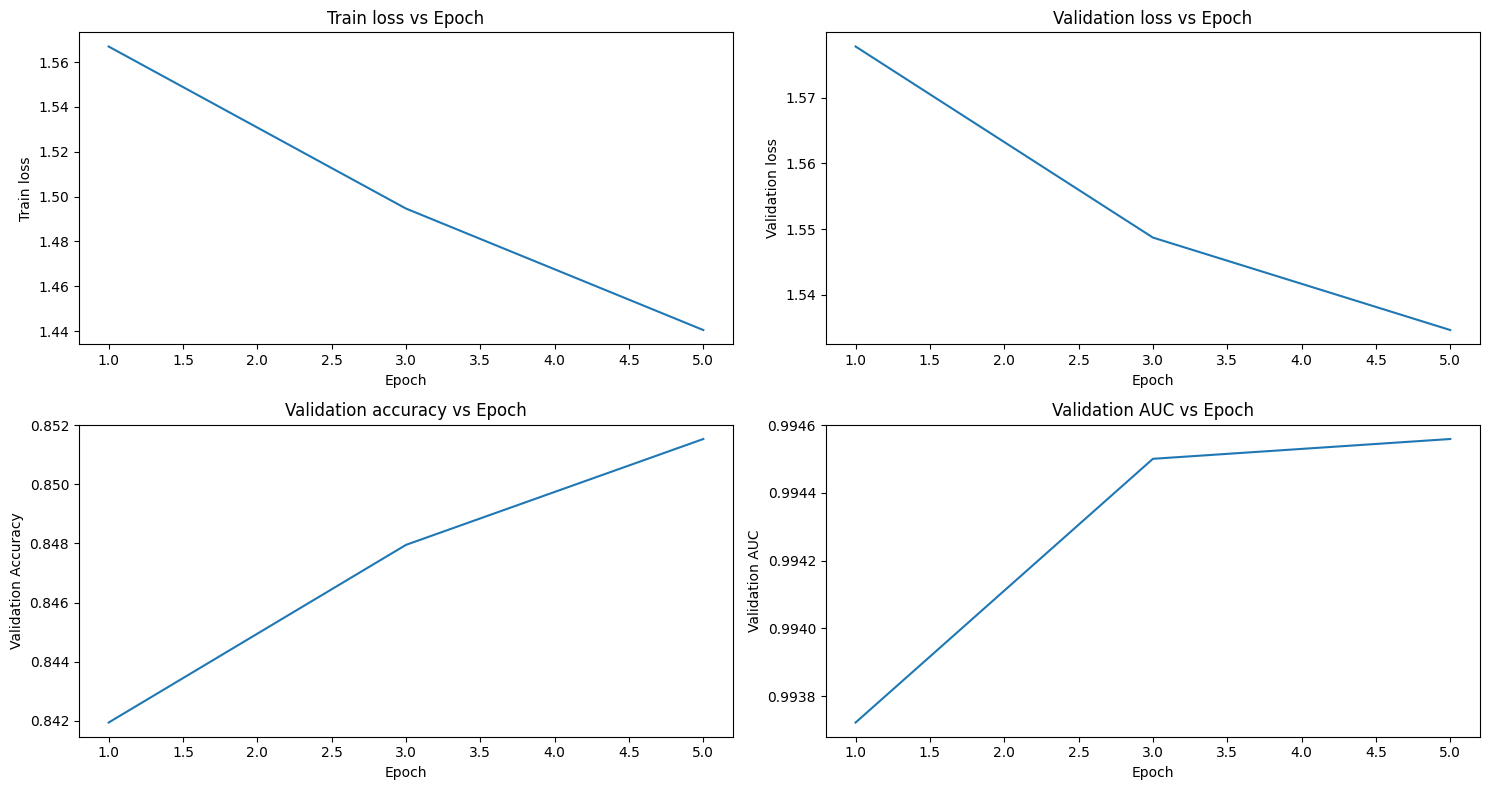

Training complete. Best val_auc: 0.9946


,epoch,train loss,validation loss,validation accuracy,validation auc
0,1,1.566915,1.577815,0.841936,0.993722
1,3,1.494672,1.548709,0.847953,0.994500
2,5,1.440517,1.534622,0.851538,0.994559


In [60]:
run_function = {
    'train_online': train_online,
    'train_offline': train_offline,
    'submit': submit
}

run_function['train_offline']()

In [34]:
def submit():

    # Class labels from taxonomy.csv
    class_labels = pd.read_csv('/kaggle/input/competitions/birdclef-2026/taxonomy.csv')['primary_label'].tolist()
    
    # List of test soundscapes (only visible during submission)
    test_soundscape_path = '/kaggle/input/competitions/birdclef-2026/test_soundscapes/'
    test_soundscapes = [os.path.join(test_soundscape_path, afile) for afile in sorted(os.listdir(test_soundscape_path)) if afile.endswith('.ogg')]
    
    # Open each soundscape and make predictions for 5-second segments
    # Use pandas df with 'row_id' plus class labels as columns
    predictions = pd.DataFrame(columns=['row_id'] + class_labels)
    for soundscape in test_soundscapes:
        print(soundscape)
        # Load audio
        sig, rate = librosa.load(path=soundscape, sr=32000)
    
        # Split into 5-second chunks
        chunks = []
        for i in range(0, len(sig), rate*5):
            chunk = sig[i:i+rate*5]
            chunks.append(chunk)
            
        # Make predictions for each chunk
        head.eval()
        with torch.no_grad():
            for i, chunk in enumerate(chunks):
                
                # Get row id  (soundscape id + end time of 5s chunk)      
                row_id = os.path.basename(soundscape).split('.')[0] + f'_{i * 5 + 5}'
        
                if len(chunk) < rate * 5:
                    chunk = np.pad(chunk, (0, rate * 5 - len(chunk)))
                
                # Transform the waveform into a melspectrogram to be able to feed in to the pretrained imagenet_b0 model
                # waveform = torch.tensor(chunk).unsqueeze(0)  # (1, samples)
                emb = extract_embedding(chunk)
                preds = head(torch.from_numpy(emb))
                probs = torch.softmax(preds, dim=1).cpu().numpy()[0]
                
                # Append to predictions as new row
                new_row = pd.DataFrame([[row_id] + list(probs)], columns=['row_id'] + class_labels)
                predictions = pd.concat([predictions, new_row], axis=0, ignore_index=True)
            
    # Save prediction as csv
    predictions.to_csv('submission.csv', index=False)
    #predictions.head()

In [53]:
def train_online():

    if use_previous_model:
        head_path = '/kaggle/input/datasets/dangthaigiang/perch-v2-cpu-onnx-head/perch_v2_cpu_onnx_head.pth'
        head.load_state_dict(torch.load(head_path, weights_only = False, map_location = device))

    chunks_df = pd.read_parquet('/kaggle/input/datasets/dangthaigiang/perch-v2-cpu-onnx-head/chunks.parquet')
    
    BATCH_SIZE  = 512
    NUM_EPOCHS  = 2
    CHECK_OUT_FREQUENCY = 50 # checkout best model every CHECK_OUT_FREQUENCY
    LR          = 1e-3
    N         = len(chunks_df) # number of chunks
    EMB_CACHE = Path('/kaggle/input/datasets/dangthaigiang/perch-v2-cpu-onnx-head/perch_embeddings.npy')
    LBL_CACHE = Path('/kaggle/input/datasets/dangthaigiang/perch-v2-cpu-onnx-head/perch_labels.npy')
    
    embeddings = np.memmap(EMB_CACHE, dtype='float32', mode='r', shape=(N, EMBED_DIM))
    labels     = np.memmap(LBL_CACHE, dtype='int64',   mode='r', shape=(N,))
    
    print('Device: ', device)
    head.to(device)

    # ---- Dataset from cached numpy arrays ----
    X = torch.from_numpy(embeddings)   # (N, 1536) float32
    y = torch.from_numpy(labels)       # (N,)      int64
    
    dataset = TensorDataset(X, y)
    n_train = int(0.8 * len(dataset))
    n_val   = int(0.1 * len(dataset))
    n_test  = len(dataset) - n_train - n_val
    train_ds, val_ds, test_ds = random_split(dataset, [n_train, n_val, n_test],
                                              generator=torch.Generator().manual_seed(42))
    
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    optimizer = torch.optim.AdamW(head.parameters(), lr=LR, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

    base_dir = Path('/kaggle/working/')
    previous_run_num = len([p for p in base_dir.iterdir() if p.is_dir() and p.name.isdigit()])
    use_last_run = False
    if use_last_run and previous_run_num!=0:
        head.load_state_dict(torch.load(str(base_dir/str(previous_run_num)/'best_model.pth'), weights_only = False, map_location = device))
    
    run_dir = base_dir / str(previous_run_num+1)
    run_dir.mkdir(parents=True, exist_ok=True)
    print(f'Saving models to: {run_dir}')
    
    best_val_loss = float('inf')
    train_history = []
        
    for epoch in tqdm(range(NUM_EPOCHS), desc=f'Training {NUM_EPOCHS} epochs ...'):
        # --- train ---
        head.train()
        train_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(head(xb), yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # --- validate ---
        head.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = head(xb)
                val_loss += criterion(preds, yb).item()
                correct  += (preds.argmax(1) == yb).sum().item()
                total    += len(yb)

        train_loss /= len(train_loader)
        val_loss   /= len(val_loader)
        val_acc     = correct / total
        train_history.append({'epoch': epoch, 'train loss': train_loss, 'validation loss': val_loss, 'validation accuracy': val_acc})
        scheduler.step()
        
        if (epoch+1)%CHECK_OUT_FREQUENCY == 0:
            print(f'Epoch {epoch+1:02d}/{NUM_EPOCHS}  '
                f'train={train_loss:.4f}  val={val_loss:.4f}  acc={val_acc:.4f}')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(head.state_dict(), run_dir / 'best_model.pth')
    torch.save(head.state_dict(), run_dir / 'last_model.pth')
    train_history_df = pd.DataFrame(train_history)
    train_history_df.to_csv(run_dir/'train_history.csv')
    plot_train_history(train_history_df)
    
    print(f'Training complete. Best val loss: {best_val_loss:.4f}')

    

In [32]:
MODE = 'train_offline'
if MODE == 'train_online':
    train_online()
elif MODE == 'train_offline':
    train_offline()
elif MODE == 'submit':
    submit()

FileNotFoundError: [Errno 2] No such file or directory: '../data/perch_labels_206.npy'

In [ ]:
train_history_df = pd.DataFrame(columns=['epoch', 'train loss', 'validation loss', 'validation accuracy'])